In [15]:
import os
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns

In [16]:
df_info = pd.read_csv('survey_results_schema.csv')
df = pd.read_csv('survey_results_public.csv',low_memory=False)

In [17]:
display(df_info.head())
display(df_info.info())
display(df.head())
display(df.info())

,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   qid       139 non-null    object 
 1   qname     139 non-null    object 
 2   question  139 non-null    object 
 3   type      139 non-null    object 
 4   sub       49 non-null     object 
 5   sq_id     49 non-null     float64
dtypes: float64(1), object(5)
memory usage: 6.6+ KB


None

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


None

### Завдання 1. Підрахунок загальної кількості респондентів

In [18]:
total_respondents = df.shape[0]

print(f"Загальна кількість респондентів: {total_respondents}")

Загальна кількість респондентів: 49191


### Завдання 2. Аналіз повноти відповідей респондентів

In [19]:
schema_questions = set(df_info['qname'])
data_columns = set(df.columns)

common_questions = list(schema_questions.intersection(data_columns))

print(f"Кількість питань для аналізу: {len(common_questions)}")

df_filtered = df[common_questions]

complete_responses = df_filtered.dropna()

final_count = len(complete_responses)

print(f"Кількість респондентів, які відповіли на всі запитання: {final_count}")

Кількість питань для аналізу: 126
Кількість респондентів, які відповіли на всі запитання: 0


### Завдання 3. Статистичний аналіз досвіду респондентів**


In [20]:
missing_workexp = df['WorkExp'].isna().sum()
print(f"Пропущених значень у колонці WorkExp: {missing_workexp}")

work_responses = pd.Series({
    'Середнє': df['WorkExp'].mean().round(2),
    'Медіана': df['WorkExp'].median(),
    'Мода': df['WorkExp'].mode()[0]
})
display(work_responses.to_frame(name='Значення'))

Пропущених значень у колонці WorkExp: 6298


,Значення
Середнє,13.37
Медіана,10.00
Мода,10.00


### **Завдання 4. Аналіз віддаленої роботи**

In [21]:
work_format_counts = df['RemoteWork'].value_counts()
display(work_format_counts)

remote_count = work_format_counts.get('Remote', 0)

remote_only = pd.DataFrame({
    'Кількість': [remote_count]
}, index=['Віддалений формат (Remote)'])

display(remote_only)

RemoteWork
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64

,Кількість
Віддалений формат (Remote),10931


### **Завдання 5. Визначення популярності Python**

In [22]:
python_users = df['LanguageHaveWorkedWith'].str.contains('Python', na=False).sum()

total_answered_lang = df['LanguageHaveWorkedWith'].dropna().count()

python_pct = (python_users / total_answered_lang) * 100

print(f"Відсоток серед тих, хто відповів на питання про мови: {python_pct:.2f}%")
print(f"Відсоток від загальної кількості анкет: {(python_users / len(df)) * 100:.2f}%")

Відсоток серед тих, хто відповів на питання про мови: 58.31%
Відсоток від загальної кількості анкет: 37.54%


### **Завдання 6. Аналіз шляхів навчання програмуванню**

In [23]:
online_learners_count = df['LearnCode'].str.contains('Online Courses', na=False).sum()

result_table = pd.DataFrame({
    'Кількість респондентів': [online_learners_count]
}, index=['Навчання через онлайн-курси'])

display(result_table)

,Кількість респондентів
Навчання через онлайн-курси,10973


### Завдання 7: Компенсація по країнах Тут комбінуємо фільтрацію та групування. 

In [24]:
python_devs = df[df['LanguageHaveWorkedWith'].str.contains('Python', na=False)].copy()

geo_compensation = python_devs.groupby('Country')['ConvertedCompYearly'].agg([
    'mean', 
    'median'
]).reset_index()

geo_compensation.columns = ['Країна', 'Середня зарплата', 'Медіанна зарплата']
geo_compensation['Середня зарплата'] = geo_compensation['Середня зарплата'].round(2)
geo_compensation = geo_compensation.sort_values(by='Медіанна зарплата', ascending=False)

display(geo_compensation.head(10))

#Для більш релевантного підрахунку виключимо країни у яких менше 30 розробників
geo_analysis = python_devs.groupby('Country')['ConvertedCompYearly'].agg([
    'count', 'mean', 'median'
]).reset_index()



top_countries = geo_analysis[geo_analysis['count'] >= 30].sort_values('median', ascending=False)
top_countries.columns = ['Країна','Всього програмістів', 'Середня зарплата', 'Медіанна зарплата']
display(top_countries.head(10))

,Країна,Середня зарплата,Медіанна зарплата
112,Oman,390135.00,390135.0
3,Andorra,226103.50,226103.5
159,United States of America,173298.59,150000.0
72,Israel,135828.37,142594.0
145,Switzerland,156456.60,142592.0
109,Nomadic,120131.57,139218.0
70,Ireland,120523.92,116015.0
87,Luxembourg,116014.71,109054.0
81,Kyrgyzstan,106008.50,106008.5
16,Belize,102121.00,102121.0


,Країна,Всього програмістів,Середня зарплата,Медіанна зарплата
159,United States of America,3126,173298.590211,150000.0
72,Israel,104,135828.365385,142594.0
145,Switzerland,240,156456.600000,142592.0
70,Ireland,74,120523.918919,116015.0
42,Denmark,120,115672.425000,98289.0
8,Australia,307,118091.410423,97514.0
157,United Kingdom of Great Britain and Northern I...,750,117662.362667,94958.5
134,Singapore,41,147515.121951,91391.0
111,Norway,88,104690.125000,89439.0
28,Canada,492,102846.026423,87550.0


### Завдання 8. Аналіз освіти найбільш оплачуваних спеціалістів

,Річна компенсація ($),Рівень освіти
34267,50000000.0,"Associate degree (A.A., A.S., etc.)"
28700,33552715.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
43143,18387548.0,"Associate degree (A.A., A.S., etc.)"
35353,15430267.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
45971,13921760.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"


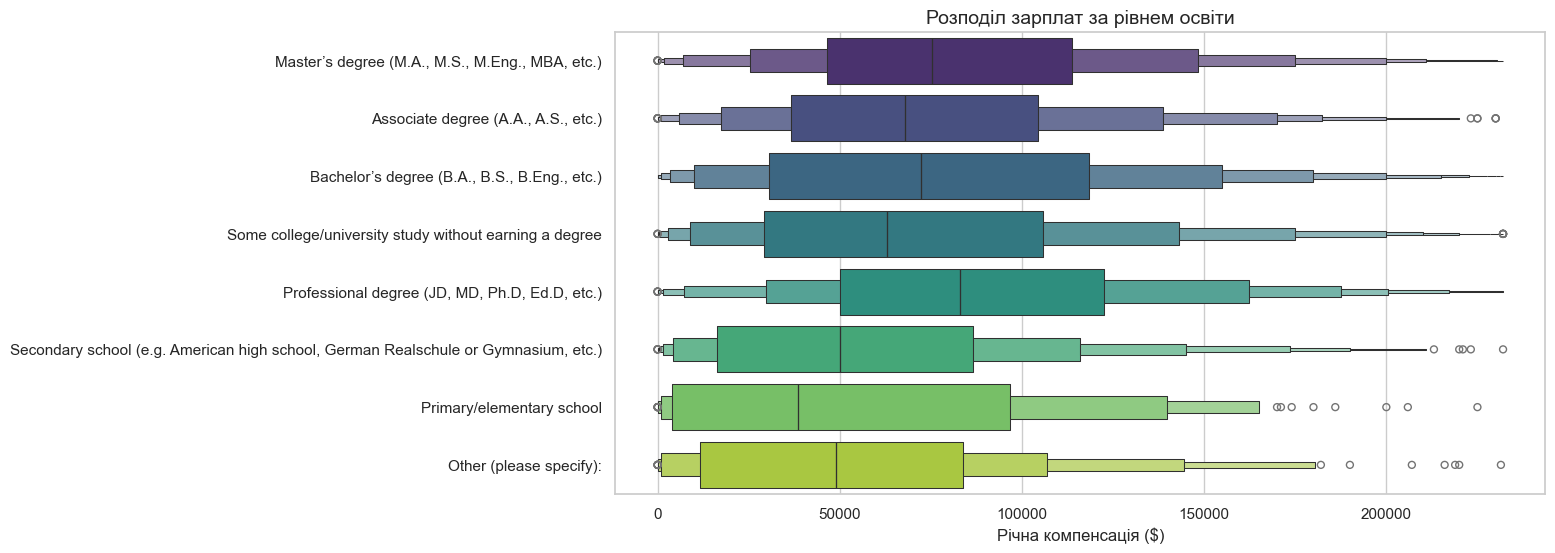

In [25]:
top_paid_data = df.dropna(subset=['ConvertedCompYearly'])

top_5_specialists = top_paid_data.nlargest(5, 'ConvertedCompYearly')

result = top_5_specialists[['ConvertedCompYearly', 'EdLevel']]

result.columns = ['Річна компенсація ($)', 'Рівень освіти']

display(result)

quantile_95 = top_paid_data['ConvertedCompYearly'].quantile(0.95)
data_plot = top_paid_data[top_paid_data['ConvertedCompYearly']<=quantile_95]

plt.figure(figsize=(12,6))
sns.boxenplot(data_plot,x='ConvertedCompYearly',y='EdLevel', palette='viridis', hue='EdLevel', legend=False)

plt.title('Розподіл зарплат за рівнем освіти', fontsize=14)
plt.xlabel('Річна компенсація ($)')
plt.ylabel('')

plt.show()

### Завдання 9. Аналіз популярності Python по віковим категоріям

,Вікова категорія,Відсоток Python-розробників (%)
0,18-24 years old,71.87
1,25-34 years old,59.49
2,35-44 years old,54.23
3,45-54 years old,54.07
4,55-64 years old,49.24
5,65 years or older,43.95


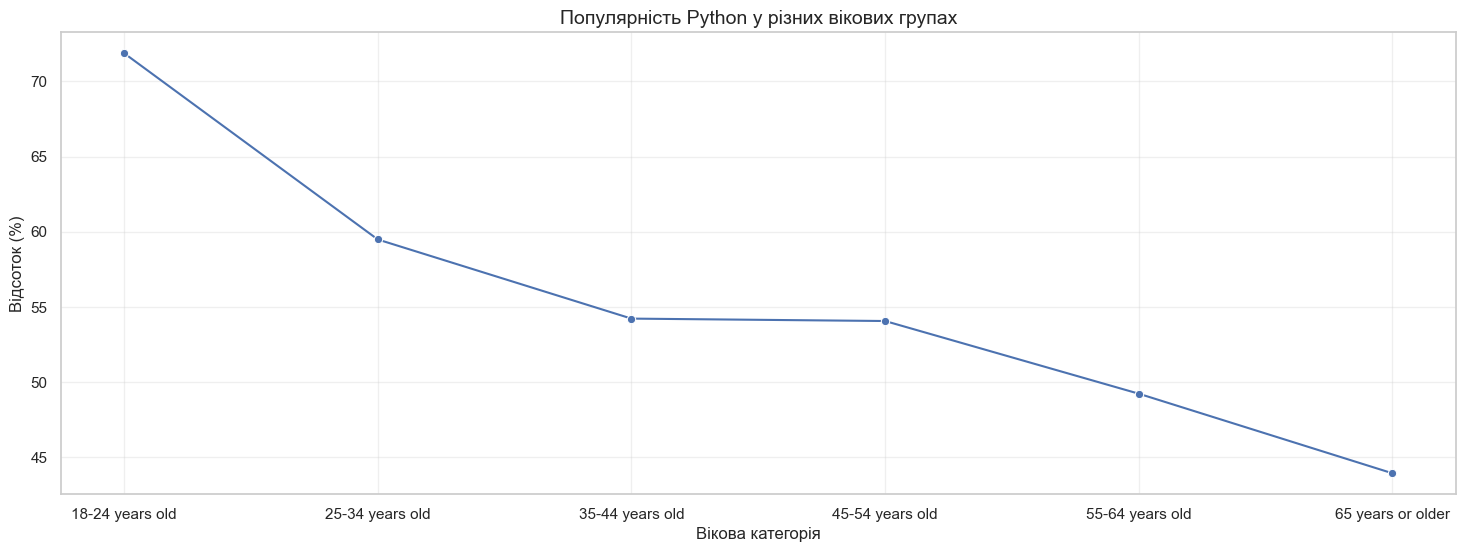

In [26]:
python_age_df = df[df['LanguageHaveWorkedWith'].notna()].copy()
python_age_df['is_python'] = python_age_df['LanguageHaveWorkedWith'].str.contains('Python', na=False)
age_analysis = python_age_df[python_age_df['Age']!='Prefer not to say']
age_analysis = age_analysis.groupby('Age')['is_python'].mean() * 100

age_analysis = age_analysis.round(2).reset_index()
age_analysis.columns = ['Вікова категорія', 'Відсоток Python-розробників (%)']

age_analysis = age_analysis.sort_values(by='Відсоток Python-розробників (%)', ascending=False)

display(age_analysis)

threshold_75 = df['ConvertedCompYearly'].quantile(0.75)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(18,6))
ax = sns.lineplot(age_analysis, x='Вікова категорія', y='Відсоток Python-розробників (%)',marker='o')

plt.title('Популярність Python у різних вікових групах', fontsize=14)
plt.ylabel('Відсоток (%)')
plt.grid(True, alpha=0.3)
plt.show()


### Завдання 10. Аналіз індустрій серед високооплачуваних віддалених працівників

,Індустрія,Кількість,Відсоток (%)
0,Software Development,1186,48.21
1,Fintech,190,7.72
2,Healthcare,188,7.64
3,Other:,176,7.15
4,"Internet, Telecomm or Information Services",138,5.61
5,Banking/Financial Services,88,3.58
6,Government,78,3.17
7,Media & Advertising Services,75,3.05
8,Retail and Consumer Services,65,2.64
9,"Transportation, or Supply Chain",63,2.56


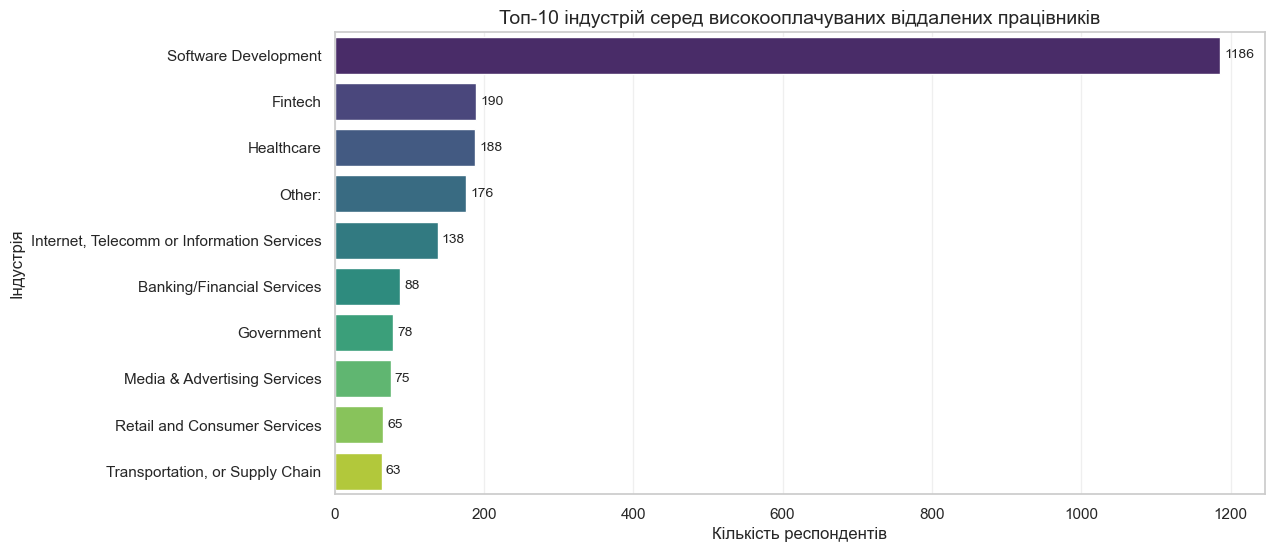

In [27]:
threshold_75 = df['ConvertedCompYearly'].quantile(0.75)

high_earners_remote = df[(df['RemoteWork'] == 'Remote') & (df['ConvertedCompYearly'] >= threshold_75)].copy()

industry_stats = high_earners_remote['Industry'].value_counts().reset_index()
industry_stats.columns = ['Індустрія', 'Кількість']

total_high_remote = industry_stats['Кількість'].sum()
industry_stats['Відсоток (%)'] = ((industry_stats['Кількість'] / total_high_remote) * 100).round(2)

display(industry_stats)

industry_stats = industry_stats.head(10)
plt.figure(figsize=(12,6))
ax = sns.barplot(industry_stats, x='Кількість', y='Індустрія', palette='viridis', hue='Індустрія')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Топ-10 індустрій серед високооплачуваних віддалених працівників', fontsize=14)
plt.xlabel('Кількість респондентів')
plt.ylabel('Індустрія')
plt.grid(axis='x', alpha=0.3)
plt.show()